In [39]:
from pathlib import Path

import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

data = pd.read_csv(
    project_root
    / "data"
    / "processed"
    / "nhanes_2017_2018_enriched.csv"
)

data = data[
    data["diabetes_diagnosis_code"].isin([2, 3])
].copy()

numeric_features = [
    "age",
    "bmi",
    "waist_cm",
    "avg_systolic_bp",
    "avg_diastolic_bp",
    "recreation_met_minutes_week",
    "sedentary_minutes",
    "average_sleep_hours"
]

categorical_features = [
    "sex_code",
    "race_ethnicity_code",
    "smoking_status"
]

feature_columns = numeric_features + categorical_features

X = data[feature_columns]
y = data["elevated_a1c"]

X_development, X_test, y_development, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Development rows:", X_development.shape[0])
print("Untouched test rows:", X_test.shape[0])

Development rows: 3560
Untouched test rows: 891


In [40]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [41]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": "recall",
    "f1": "f1"
}

In [42]:
comparison_rows = []

for model_name, classifier in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", classifier)
        ]
    )

    scores = cross_validate(
        pipeline,
        X_development,
        y_development,
        cv=cross_validation,
        scoring=scoring,
        n_jobs=-1
    )

    comparison_rows.append(
        {
            "model": model_name,
            "roc_auc_mean": scores["test_roc_auc"].mean(),
            "roc_auc_std": scores["test_roc_auc"].std(),
            "pr_auc_mean": scores["test_pr_auc"].mean(),
            "recall_mean": scores["test_recall"].mean(),
            "f1_mean": scores["test_f1"].mean()
        }
    )

comparison = pd.DataFrame(comparison_rows)
comparison = comparison.set_index("model")

comparison.round(3).sort_values(
    "roc_auc_mean",
    ascending=False
)

,roc_auc_mean,roc_auc_std,pr_auc_mean,recall_mean,f1_mean
model,,,,,
Logistic Regression,0.784,0.011,0.617,0.508,0.56
Gradient Boosting,0.775,0.017,0.610,0.518,0.56
Random Forest,0.771,0.020,0.603,0.493,0.54


In [43]:
import numpy as np

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import cross_val_predict

In [44]:
selected_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(max_iter=1000)
        )
    ]
)

development_probabilities = cross_val_predict(
    selected_model,
    X_development,
    y_development,
    cv=cross_validation,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_development,
        development_probabilities
    )
)

target_recall = 0.75

valid_thresholds = recall_values[:-1] >= target_recall

candidate_thresholds = thresholds[valid_thresholds]
candidate_precisions = precision_values[:-1][valid_thresholds]

best_candidate_index = np.argmax(candidate_precisions)

selected_threshold = candidate_thresholds[
    best_candidate_index
]

development_predictions = (
    development_probabilities >= selected_threshold
).astype(int)

print(
    "Selected threshold:",
    round(selected_threshold, 3)
)

print(
    "Development precision:",
    round(
        precision_score(
            y_development,
            development_predictions
        ),
        3
    )
)

print(
    "Development recall:",
    round(
        recall_score(
            y_development,
            development_predictions
        ),
        3
    )
)

Selected threshold: 0.347
Development precision: 0.557
Development recall: 0.751


In [45]:
selected_model.fit(
    X_development,
    y_development
)

test_probabilities = selected_model.predict_proba(
    X_test
)[:, 1]

default_predictions = (
    test_probabilities >= 0.50
).astype(int)

tuned_predictions = (
    test_probabilities >= selected_threshold
).astype(int)


def calculate_metrics(name, predictions):
    return {
        "configuration": name,
        "accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "precision": precision_score(
            y_test,
            predictions
        ),
        "recall": recall_score(
            y_test,
            predictions
        ),
        "f1": f1_score(
            y_test,
            predictions
        ),
        "roc_auc": roc_auc_score(
            y_test,
            test_probabilities
        )
    }


threshold_results = pd.DataFrame(
    [
        calculate_metrics(
            "Default threshold",
            default_predictions
        ),
        calculate_metrics(
            "Tuned threshold",
            tuned_predictions
        )
    ]
).set_index("configuration")

threshold_results.round(3)

,accuracy,precision,recall,f1,roc_auc
configuration,,,,,
Default threshold,0.706,0.600,0.465,0.524,0.753
Tuned threshold,0.675,0.525,0.687,0.595,0.753


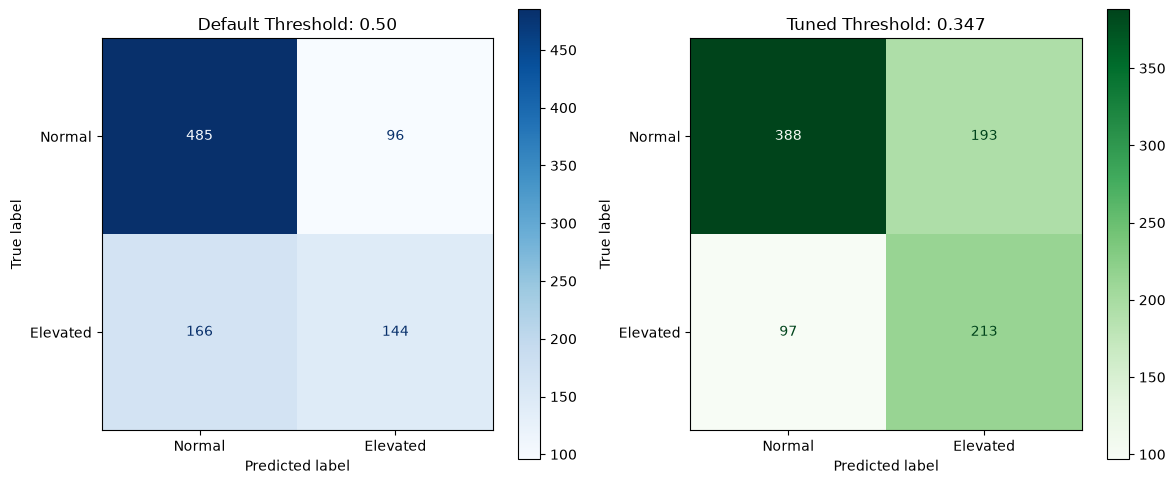

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    default_predictions,
    display_labels=["Normal", "Elevated"],
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("Default Threshold: 0.50")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_predictions,
    display_labels=["Normal", "Elevated"],
    cmap="Greens",
    ax=axes[1]
)

axes[1].set_title(
    f"Tuned Threshold: {selected_threshold:.3f}"
)

plt.tight_layout()
plt.show()

Model Brier score:    0.189
Baseline Brier score: 0.227


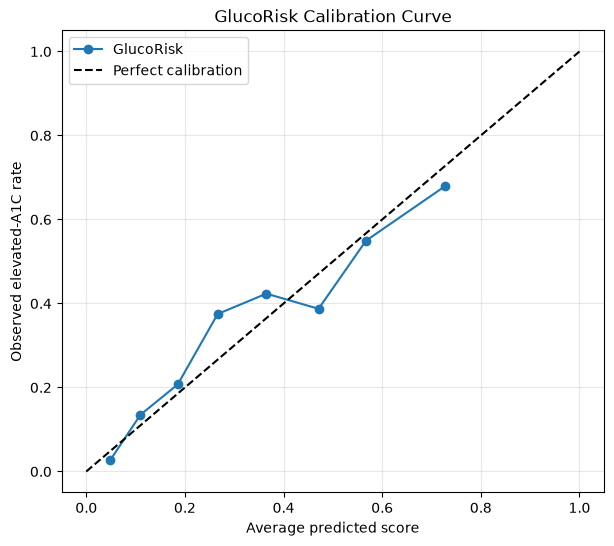

In [47]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

actual_rate, predicted_rate = calibration_curve(
    y_test,
    test_probabilities,
    n_bins=8,
    strategy="quantile",
)

model_brier = brier_score_loss(y_test, test_probabilities)

baseline_probabilities = np.full(
    len(y_test),
    y_development.mean(),
)

baseline_brier = brier_score_loss(
    y_test,
    baseline_probabilities,
)

print(f"Model Brier score:    {model_brier:.3f}")
print(f"Baseline Brier score: {baseline_brier:.3f}")

plt.figure(figsize=(7, 6))

plt.plot(
    predicted_rate,
    actual_rate,
    marker="o",
    label="GlucoRisk",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Perfect calibration",
)

plt.xlabel("Average predicted score")
plt.ylabel("Observed elevated-A1C rate")
plt.title("GlucoRisk Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [48]:
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)

audit_data = X_test[
    ["sex_code", "race_ethnicity_code"]
].copy()

audit_data["actual"] = np.asarray(y_test)
audit_data["prediction"] = tuned_predictions
audit_data["score"] = test_probabilities

audit_data["sex"] = audit_data["sex_code"].map({
    1.0: "Male",
    2.0: "Female",
})

audit_data["race_ethnicity"] = audit_data[
    "race_ethnicity_code"
].map({
    1.0: "Mexican American",
    2.0: "Other Hispanic",
    3.0: "Non-Hispanic White",
    4.0: "Non-Hispanic Black",
    6.0: "Non-Hispanic Asian",
    7.0: "Other / Multiracial",
})


def calculate_group_metrics(data, group_column):
    results = []

    for group_name, group in data.groupby(
        group_column,
        dropna=False,
    ):
        actual = group["actual"]
        prediction = group["prediction"]

        tn, fp, fn, tp = confusion_matrix(
            actual,
            prediction,
            labels=[0, 1],
        ).ravel()

        auc = (
            roc_auc_score(actual, group["score"])
            if actual.nunique() == 2
            else np.nan
        )

        results.append({
            "group": group_name,
            "sample_size": len(group),
            "elevated_cases": int(actual.sum()),
            "precision": precision_score(
                actual,
                prediction,
                zero_division=0,
            ),
            "recall": recall_score(
                actual,
                prediction,
                zero_division=0,
            ),
            "false_positive_rate": (
                fp / (fp + tn)
                if (fp + tn) > 0
                else np.nan
            ),
            "roc_auc": auc,
        })

    return (
        pd.DataFrame(results)
        .set_index("group")
        .round(3)
    )


sex_results = calculate_group_metrics(
    audit_data,
    "sex",
)

race_results = calculate_group_metrics(
    audit_data,
    "race_ethnicity",
)

print("Results by sex:")
display(sex_results)

print("Results by race and ethnicity:")
display(race_results)

Results by sex:


,sample_size,elevated_cases,precision,recall,false_positive_rate,roc_auc
group,,,,,,
Female,457,152,0.517,0.697,0.325,0.753
Male,434,158,0.532,0.677,0.341,0.753


Results by race and ethnicity:


,sample_size,elevated_cases,precision,recall,false_positive_rate,roc_auc
group,,,,,,
Mexican American,109,39,0.475,0.487,0.300,0.735
Non-Hispanic Asian,119,53,0.656,0.792,0.333,0.794
Non-Hispanic Black,209,94,0.580,0.851,0.504,0.750
Non-Hispanic White,328,91,0.455,0.560,0.257,0.738
Other / Multiracial,46,16,0.533,0.500,0.233,0.702
Other Hispanic,80,17,0.351,0.765,0.381,0.739


,feature,coefficient
0,numeric__age,0.988374
12,categorical__race_ethnicity_code_3.0,-0.758601
14,categorical__race_ethnicity_code_6.0,0.540319
17,categorical__smoking_status_1.0,-0.343098
1,numeric__bmi,0.312272
2,numeric__waist_cm,0.272408
13,categorical__race_ethnicity_code_4.0,0.258125
15,categorical__race_ethnicity_code_7.0,-0.247308
9,categorical__sex_code_2.0,-0.229191
10,categorical__race_ethnicity_code_1.0,-0.187117


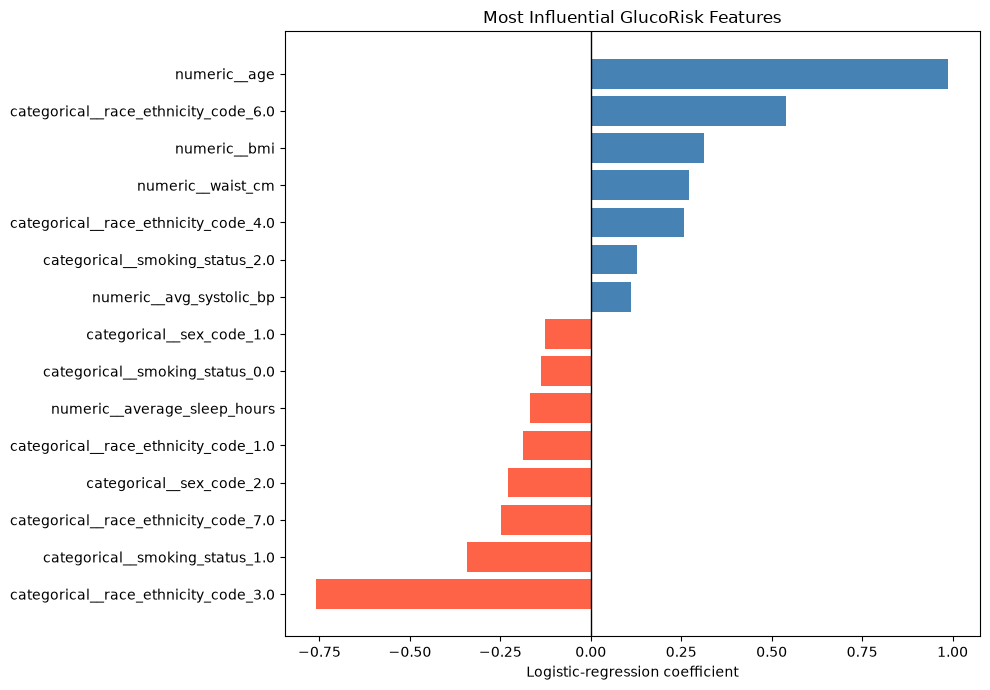

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = (
    selected_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    selected_model
    .named_steps["classifier"]
    .coef_[0]
)

coefficient_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
})

coefficient_table["absolute_coefficient"] = (
    coefficient_table["coefficient"].abs()
)

top_features = (
    coefficient_table
    .sort_values(
        "absolute_coefficient",
        ascending=False,
    )
    .head(15)
)

display(
    top_features[
        ["feature", "coefficient"]
    ]
)

plot_data = top_features.sort_values("coefficient")

colors = [
    "steelblue" if value > 0 else "tomato"
    for value in plot_data["coefficient"]
]

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["feature"],
    plot_data["coefficient"],
    color=colors,
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Logistic-regression coefficient")
plt.title("Most Influential GlucoRisk Features")
plt.tight_layout()
plt.show()

In [50]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
)

# Features that will be available to the public-facing model
deployment_numeric_features = [
    "age",
    "bmi",
    "waist_cm",
    "avg_systolic_bp",
    "avg_diastolic_bp",
    "recreation_met_minutes_week",
    "sedentary_minutes",
    "average_sleep_hours",
]

deployment_categorical_features = [
    "smoking_status",
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

deployment_preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        deployment_numeric_features,
    ),
    (
        "categorical",
        categorical_pipeline,
        deployment_categorical_features,
    ),
])

# Copy the same logistic-regression settings
deployment_model = Pipeline([
    ("preprocessor", deployment_preprocessor),
    (
        "classifier",
        clone(
            selected_model.named_steps["classifier"]
        ),
    ),
])

# Generate out-of-fold development predictions
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

development_probabilities = cross_val_predict(
    deployment_model,
    X_development,
    y_development,
    cv=cross_validation,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

# Select a threshold targeting at least 75% recall
precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_development,
        development_probabilities,
    )
)

valid_indices = np.where(
    recall_values[:-1] >= 0.75
)[0]

deployment_threshold = thresholds[
    valid_indices[-1]
]

# Fit using all development data
deployment_model.fit(
    X_development,
    y_development,
)

deployment_test_probabilities = (
    deployment_model.predict_proba(X_test)[:, 1]
)

deployment_predictions = (
    deployment_test_probabilities
    >= deployment_threshold
).astype(int)


def model_summary(
    name,
    actual,
    predictions,
    probabilities,
):
    return {
        "model": name,
        "threshold": (
            selected_threshold
            if name == "Original model"
            else deployment_threshold
        ),
        "accuracy": accuracy_score(
            actual,
            predictions,
        ),
        "precision": precision_score(
            actual,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            actual,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            actual,
            predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            actual,
            probabilities,
        ),
    }


comparison = pd.DataFrame([
    model_summary(
        "Original model",
        y_test,
        tuned_predictions,
        test_probabilities,
    ),
    model_summary(
        "Without sex or race",
        y_test,
        deployment_predictions,
        deployment_test_probabilities,
    ),
]).set_index("model").round(3)

display(comparison)

# Audit the new model using demographic columns
deployment_audit = audit_data.copy()
deployment_audit["prediction"] = deployment_predictions
deployment_audit["score"] = deployment_test_probabilities

print("New model results by sex:")
display(
    calculate_group_metrics(
        deployment_audit,
        "sex",
    )
)

print("New model results by race and ethnicity:")
display(
    calculate_group_metrics(
        deployment_audit,
        "race_ethnicity",
    )
)

,threshold,accuracy,precision,recall,f1,roc_auc
model,,,,,,
Original model,0.347,0.675,0.525,0.687,0.595,0.753
Without sex or race,0.338,0.660,0.508,0.713,0.593,0.728


New model results by sex:


,sample_size,elevated_cases,precision,recall,false_positive_rate,roc_auc
group,,,,,,
Female,457,152,0.489,0.730,0.380,0.724
Male,434,158,0.529,0.696,0.355,0.732


New model results by race and ethnicity:


,sample_size,elevated_cases,precision,recall,false_positive_rate,roc_auc
group,,,,,,
Mexican American,109,39,0.511,0.615,0.329,0.740
Non-Hispanic Asian,119,53,0.698,0.566,0.197,0.788
Non-Hispanic Black,209,94,0.598,0.777,0.426,0.747
Non-Hispanic White,328,91,0.426,0.791,0.409,0.736
Other / Multiracial,46,16,0.526,0.625,0.300,0.708
Other Hispanic,80,17,0.343,0.706,0.365,0.742


In [52]:
from pathlib import Path
import json
import joblib

project_root = Path.cwd()

# Handles Jupyter being launched from either the project
# directory or the notebooks directory
if project_root.name == "notebooks":
    project_root = project_root.parent

model_directory = project_root / "models"
model_directory.mkdir(parents=True, exist_ok=True)

model_path = model_directory / "glucorisk_model.joblib"
metadata_path = model_directory / "model_metadata.json"

joblib.dump(
    deployment_model,
    model_path,
)

model_metadata = {
    "model_name": "GlucoRisk",
    "version": "1.0.0",
    "model_type": "Logistic Regression",
    "decision_threshold": float(deployment_threshold),
    "prediction_target": "Elevated A1C of 5.7% or higher",
    "dataset": "NHANES 2017-2018",
    "population": (
        "Adults without a confirmed diabetes diagnosis"
    ),
    "features": (
        deployment_numeric_features
        + deployment_categorical_features
    ),
    "excluded_sensitive_features": [
        "sex_code",
        "race_ethnicity_code",
    ],
    "test_metrics": {
        "accuracy": float(
            accuracy_score(
                y_test,
                deployment_predictions,
            )
        ),
        "precision": float(
            precision_score(
                y_test,
                deployment_predictions,
                zero_division=0,
            )
        ),
        "recall": float(
            recall_score(
                y_test,
                deployment_predictions,
                zero_division=0,
            )
        ),
        "f1": float(
            f1_score(
                y_test,
                deployment_predictions,
                zero_division=0,
            )
        ),
        "roc_auc": float(
            roc_auc_score(
                y_test,
                deployment_test_probabilities,
            )
        ),
    },
    "limitations": [
        "Not a medical diagnosis",
        "Not clinically validated",
        "Trained using cross-sectional survey data",
        "May perform differently across demographic groups",
    ],
}

with open(
    metadata_path,
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        model_metadata,
        metadata_file,
        indent=4,
    )

print(f"Model saved to: {model_path}")
print(f"Metadata saved to: {metadata_path}")

Model saved to: C:\Users\zfbro\glucorisk\models\glucorisk_model.joblib
Metadata saved to: C:\Users\zfbro\glucorisk\models\model_metadata.json
